<a href="https://colab.research.google.com/github/2001320Xochitl/2001320-Xochitl-Oliva-Estrada-IMC/blob/main/2001320_Examen_Medio_Curso_Inteligencia_Artificial_y_Redes_Neuronales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Examen Medio Curso**

**Nombre:** Xochitl Oliva Estrada

**Matricula:** 2001320

**Carrera:** IMC

**Grupo:** 008

**Materia:** Inteligencia Artificial Y Redes Neuronales

**Objetivo:** Utilizar las librerías numpy, pandas y matplotlib para procesar, limpiar y extraer información valiosa de un conjunto de datos real sobre el rendimiento y las especificaciones mecánicas de diversos motores y vehículos.

#**Parte 1: Carga y Limpieza (Pandas y NumPy)**


1. Importar Librerias

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

2. Leer el archivo CSV y guardarlo en un DataFrame

In [15]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
df = pd.read_csv(url)

3. Imprimir las primeras 5 filas y tipos de datos

In [18]:
print("Primeras 5 filas")
print(df.head())

Primeras 5 filas
    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model_year origin                       name  
0          70    usa  chevrolet chevelle malibu  
1          70    usa          buick skylark 320  
2          70    usa         plymouth satellite  
3          70    usa              amc rebel sst  
4          70    usa                ford torino  


In [19]:
print("Tipos de datos por columna")
print(df.dtypes)

Tipos de datos por columna
mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin           object
name             object
dtype: object


4. Identificar los nulos y limpiar valores nulos en 'horsepower'

In [6]:
# Identificar nulos
nulos = df['horsepower'].isnull().sum()
print(f"Valores nulos en horsepower: {nulos}")

# Reemplazar nulos con la mediana usando NumPy y Pandas
mediana_hp = df['horsepower'].median()
df['horsepower'] = df['horsepower'].fillna(mediana_hp)

print(f"Se han reemplazado los nulos con el valor: {mediana_hp}")

Valores nulos en horsepower: 6
Se han reemplazado los nulos con el valor: 93.5


5. Crear la columna 'relacion_peso_potencia'

In [7]:
df['relacion_peso_potencia'] = df['weight'] / df['horsepower']
# Mostramos las primeras filas para verificar la nueva columna
df[['weight', 'horsepower', 'relacion_peso_potencia']].head()

,weight,horsepower,relacion_peso_potencia
0,3504,130.0,26.953846
1,3693,165.0,22.381818
2,3436,150.0,22.906667
3,3433,150.0,22.886667
4,3449,140.0,24.635714


#**Parte 2: Visualización de Datos (Matplotlib)**
Ahora generamos las gráficas para interpretar el comportamiento mecánico de los motores.

1. Histograma: Distribución de la aceleración

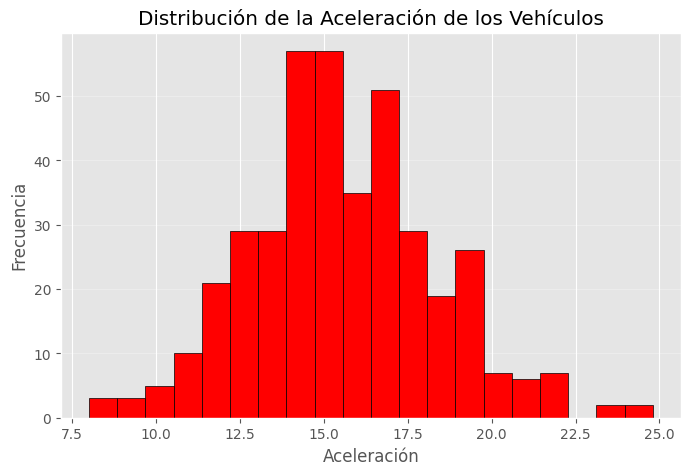

In [21]:
plt.figure(figsize=(8, 5))
plt.hist(df['acceleration'], bins=20, color='red', edgecolor='black')
plt.title('Distribución de la Aceleración de los Vehículos')
plt.xlabel('Aceleración')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.3)
plt.show()

2. Gráfico de Dispersión: Desplazamiento vs Caballos de fuerza

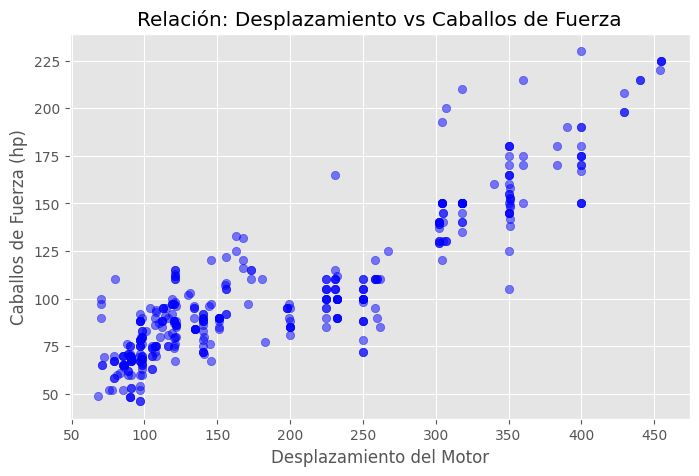

In [22]:
plt.figure(figsize=(8, 5))
plt.scatter(df['displacement'], df['horsepower'], color='blue', alpha=0.5)
plt.title('Relación: Desplazamiento vs Caballos de Fuerza')
plt.xlabel('Desplazamiento del Motor')
plt.ylabel('Caballos de Fuerza (hp)')
plt.show()

3. Gráfico de Barras: Promedio de MPG por país de origen

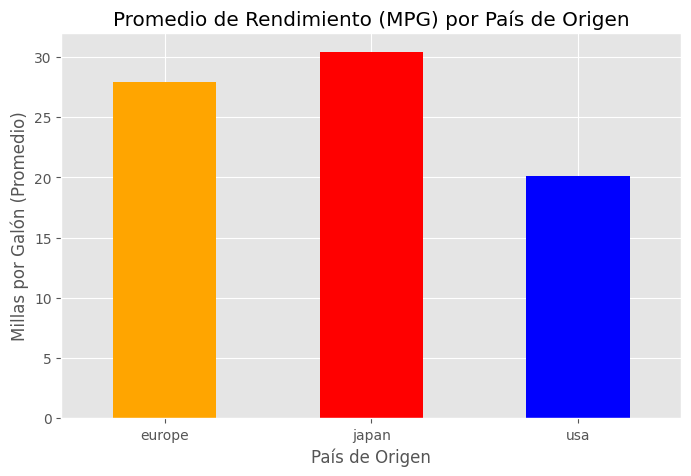

In [11]:
# Agrupar datos por país de origen y calcular el promedio de rendimiento (mpg)
mpg_promedio = df.groupby('origin')['mpg'].mean()

# Generar la gráfica
plt.figure(figsize=(8, 5))
mpg_promedio.plot(kind='bar', color=['orange', 'red', 'blue'])
plt.title('Promedio de Rendimiento (MPG) por País de Origen')
plt.xlabel('País de Origen')
plt.ylabel('Millas por Galón (Promedio)')
plt.xticks(rotation=0) # Mantiene los nombres horizontales
plt.show()